# Global Happiness Report Analysis

Exploring the 2015 World Happiness Report — what factors (GDP, social support, health, freedom, trust, generosity) actually go together with a country's happiness score, and how regions compare.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("2015.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (158, 12)


In [6]:
print(df.columns)

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


In [8]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


## 3. Data Cleaning

In [10]:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Shorten some column names for easier plotting later
df = df.rename(columns={
    "Economy (GDP per Capita)": "GDP_per_Capita",
    "Health (Life Expectancy)": "Life_Expectancy",
    "Trust (Government Corruption)": "Trust_Govt",
    "Happiness Score": "Happiness_Score",
    "Happiness Rank": "Happiness_Rank"
})
df.columns

Index(['Country', 'Region', 'Happiness_Rank', 'Happiness_Score', 'Standard Error', 'GDP_per_Capita', 'Family', 'Life_Expectancy',
       'Freedom', 'Trust_Govt', 'Generosity', 'Dystopia Residual'],
      dtype='str')

## 4. Overall Distribution of Happiness Scores

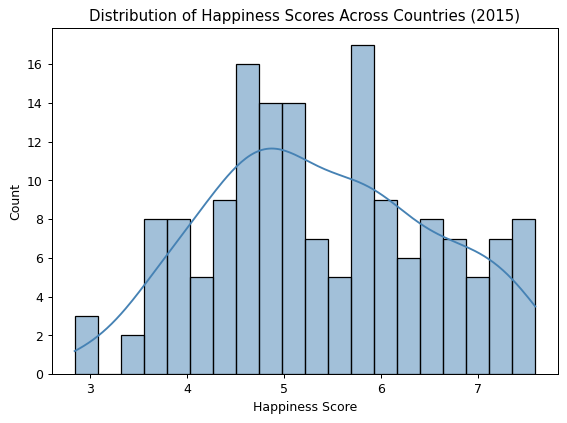

In [14]:
fig, ax = plt.subplots()
sns.histplot(df["Happiness_Score"], bins=20, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Happiness Scores Across Countries (2015)")
ax.set_xlabel("Happiness Score")
plt.tight_layout()
plt.show()

## 5. Top and Bottom 10 Happiest Countries

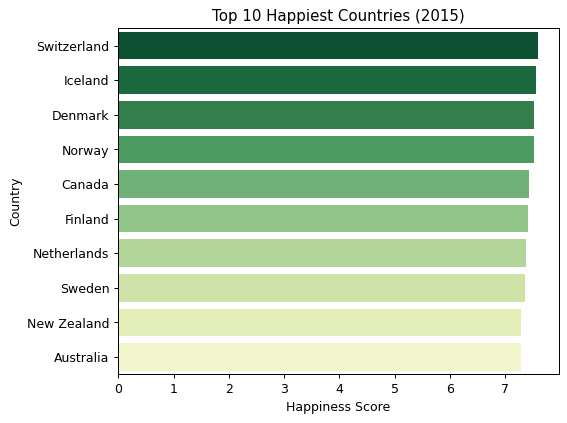

In [16]:
top10 = df.sort_values("Happiness_Score", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top10, x="Happiness_Score", y="Country", hue="Country", palette="YlGn_r", legend=False, ax=ax)
ax.set_title("Top 10 Happiest Countries (2015)")
ax.set_xlabel("Happiness Score")
plt.tight_layout()
plt.show()

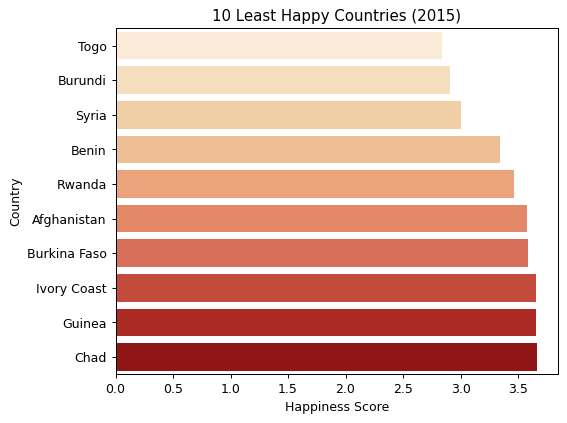

In [17]:
bottom10 = df.sort_values("Happiness_Score", ascending=True).head(10)

fig, ax = plt.subplots()
sns.barplot(data=bottom10, x="Happiness_Score", y="Country", hue="Country", palette="OrRd", legend=False, ax=ax)
ax.set_title("10 Least Happy Countries (2015)")
ax.set_xlabel("Happiness Score")
plt.tight_layout()
plt.show()

## 6. Happiness by Region

In [19]:
region_avg = df.groupby("Region")["Happiness_Score"].mean().sort_values(ascending=False)
region_avg

Region
Australia and New Zealand          7.285000
North America                      7.273000
Western Europe                     6.689619
Latin America and Caribbean        6.144682
Eastern Asia                       5.626167
Middle East and Northern Africa    5.406900
Central and Eastern Europe         5.332931
Southeastern Asia                  5.317444
Southern Asia                      4.580857
Sub-Saharan Africa                 4.202800
Name: Happiness_Score, dtype: float64

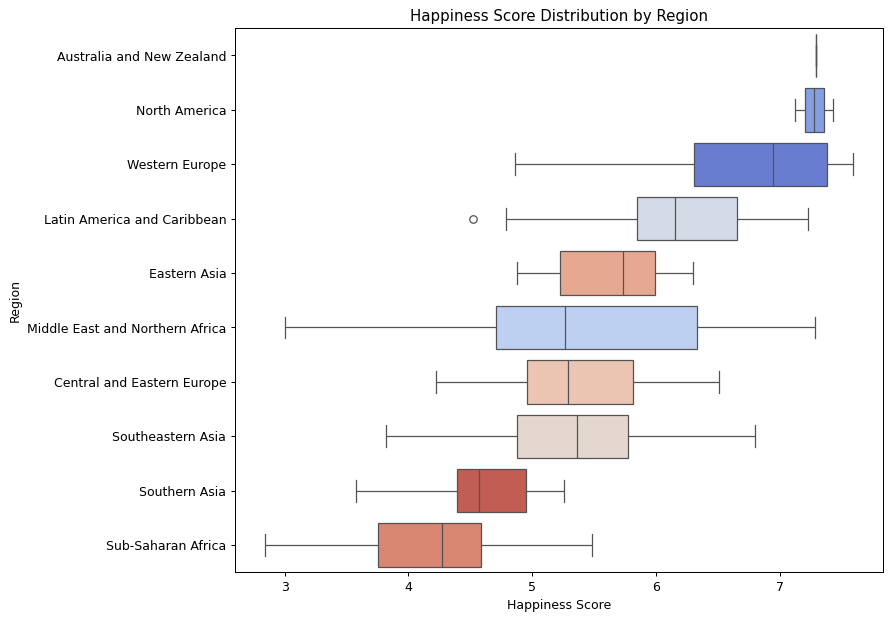

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=df, x="Happiness_Score", y="Region",
            order=region_avg.index, hue="Region", palette="coolwarm", legend=False, ax=ax)
ax.set_title("Happiness Score Distribution by Region")
ax.set_xlabel("Happiness Score")
plt.tight_layout()
plt.show()

## 7. Correlation Between Happiness and Its Contributing Factors

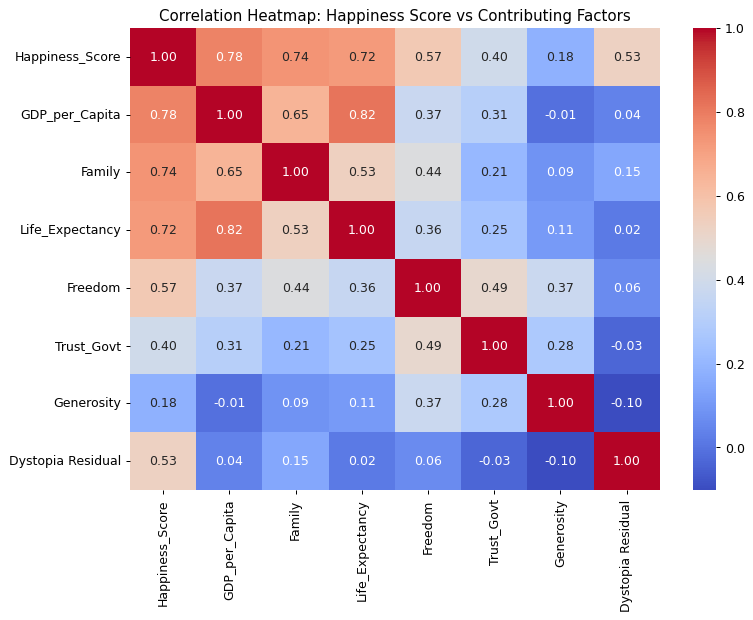

In [22]:
factor_cols = ["Happiness_Score", "GDP_per_Capita", "Family", "Life_Expectancy",
               "Freedom", "Trust_Govt", "Generosity", "Dystopia Residual"]

corr = df[factor_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap: Happiness Score vs Contributing Factors")
plt.tight_layout()
plt.show()

In [23]:
corr["Happiness_Score"].sort_values(ascending=False)

Happiness_Score      1.000000
GDP_per_Capita       0.780966
Family               0.740605
Life_Expectancy      0.724200
Freedom              0.568211
Dystopia Residual    0.530474
Trust_Govt           0.395199
Generosity           0.180319
Name: Happiness_Score, dtype: float64

## 8. Happiness vs GDP per Capita

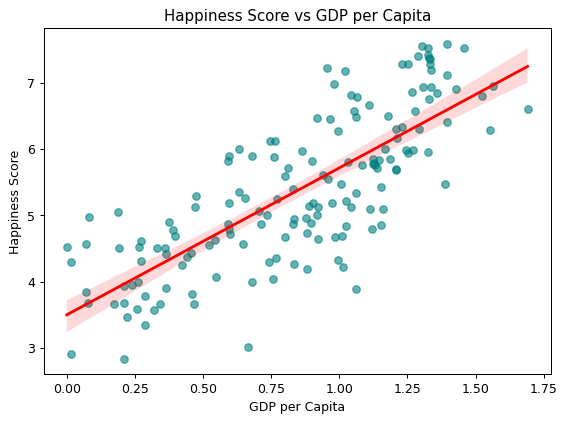

In [25]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="GDP_per_Capita", y="Happiness_Score",
            scatter_kws={"alpha": 0.6, "color": "teal"}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Happiness Score vs GDP per Capita")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

## 9. Happiness vs Social Support (Family)

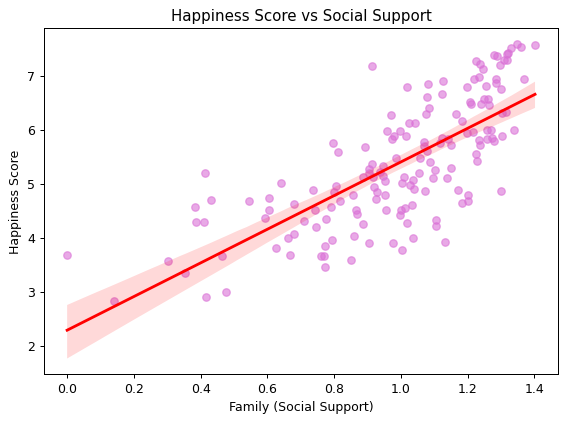

In [27]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="Family", y="Happiness_Score",
            scatter_kws={"alpha": 0.6, "color": "orchid"}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Happiness Score vs Social Support")
ax.set_xlabel("Family (Social Support)")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

## 10. Happiness vs Life Expectancy

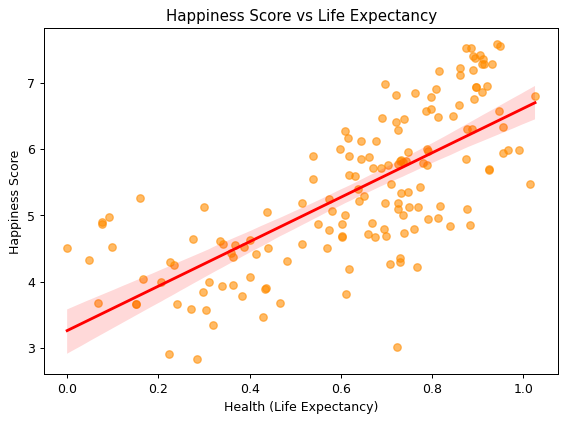

In [29]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="Life_Expectancy", y="Happiness_Score",
            scatter_kws={"alpha": 0.6, "color": "darkorange"}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Happiness Score vs Life Expectancy")
ax.set_xlabel("Health (Life Expectancy)")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

## 11. GDP, Life Expectancy and Happiness Together

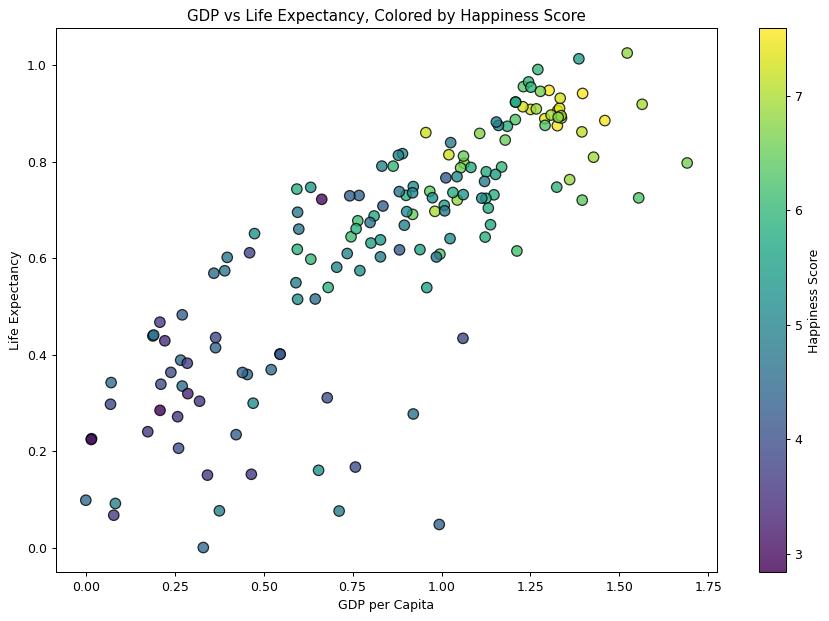

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df["GDP_per_Capita"], df["Life_Expectancy"],
                      c=df["Happiness_Score"], cmap="viridis", s=70, edgecolor="k", alpha=0.8)
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Life Expectancy")
ax.set_title("GDP vs Life Expectancy, Colored by Happiness Score")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Happiness Score")
plt.tight_layout()
plt.show()

## 12. Which Factor Matters Most? (Pairplot)

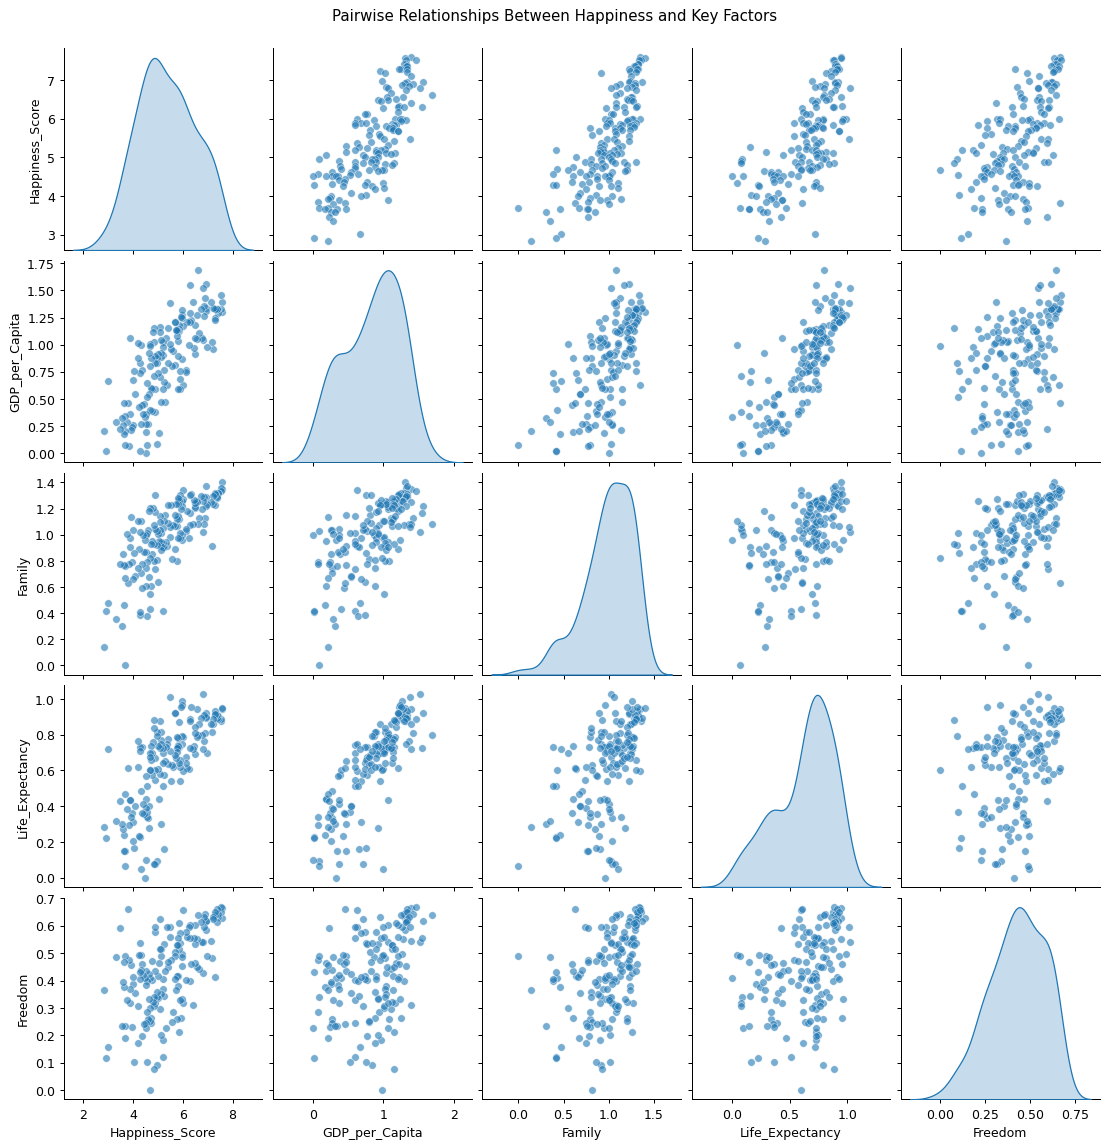

In [33]:
sns.pairplot(df[["Happiness_Score", "GDP_per_Capita", "Family", "Life_Expectancy", "Freedom"]],
             diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise Relationships Between Happiness and Key Factors", y=1.02)
plt.show()

## 13. Key Insights

- **GDP per capita, life expectancy, and social support (family)** show the strongest positive correlation with happiness score — countries that score well on these tend to be happier overall.
- **Trust in government and generosity** have a much weaker correlation with happiness compared to economic and health factors.
- **Western Europe, North America, and Australia/New Zealand** have the highest average happiness scores, while **Sub-Saharan Africa** has the lowest.
- The relationship between happiness and GDP is strong but not perfectly linear — some countries achieve high happiness scores despite modest GDP, suggesting factors like social support and freedom help compensate.
- Wealthier countries (high GDP) generally also have higher life expectancy, and both tend to cluster with higher happiness scores, visible in the combined scatter plot.
